# Production model versus simple waitlist rules

This notebook produces the apples-to-apples README benchmark. It compares the seasonal Oracle with three simple baselines: the same-course historical clearance percentage, the literal 10% rule, and a boosted 10% rule. The boosted 10% rule is a fitted probability curve that still uses only rank divided by lecture capacity. Every fold trains only on earlier sessions from the same enrollment calendar. Accuracy uses a 50% probability cutoff.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 4
RANDOM_STATE = 42
SEASONS = {
    'fall_winter': ['20229', '20239', '20249', '20259'],
    'summer': ['20235', '20245', '20255', '20265'],
}
all_sessions = [session for sessions in SEASONS.values() for session in sessions]
paths = {session: CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for session in all_sessions}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in paths.items()}
print(f'Loaded {sum(map(len, session_samples.values())):,} cached rows')

Loaded 2,379,974 cached rows


In [2]:
BASE_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
def add_targeted_features(frame):
    frame = frame.copy()
    days = frame['days_to_deadline'].clip(lower=0)
    near_7 = (days <= 7).astype('float32')
    winter = frame['term'].eq('winter').astype('float32')
    scarborough = frame['campus'].eq('SCAR').astype('float32')
    frame['near_deadline_7d'] = near_7
    frame['days_under_7'] = (7 - days).clip(lower=0).astype('float32')
    frame['days_under_14'] = (14 - days).clip(lower=0).astype('float32')
    frame['days_over_60'] = (days - 60).clip(lower=0).astype('float32')
    frame['position_ratio_near_7d'] = (frame['position_to_capacity'] * near_7).astype('float32')
    frame['waitlist_ratio_near_7d'] = (frame['waitlist_to_capacity'] * near_7).astype('float32')
    frame['rank_over_30pct'] = frame['position_to_capacity'].gt(.30).astype('float32')
    frame['campus_erin'] = frame['campus'].eq('ERIN').astype('float32')
    frame['campus_scar'] = scarborough
    frame['term_winter'] = winter
    frame['term_full_year'] = frame['term'].eq('full_year').astype('float32')
    frame['winter_near_7d'] = (winter * near_7).astype('float32')
    frame['scar_near_7d'] = (scarborough * near_7).astype('float32')
    frame['days_rounded'] = frame['days_to_deadline'].round().astype('int16')
    frame['offering_id'] = frame['session'].astype(str) + ':' + frame['course_code'] + ':' + frame['meeting']
    return frame

session_samples = {session: add_targeted_features(frame) for session, frame in session_samples.items()}
NUMERIC = BASE_NUMERIC + [
    'near_deadline_7d', 'days_under_7', 'days_under_14', 'days_over_60',
    'position_ratio_near_7d', 'waitlist_ratio_near_7d', 'rank_over_30pct',
    'campus_erin', 'campus_scar', 'term_winter', 'term_full_year',
    'winter_near_7d', 'scar_near_7d',
]
FEATURE_COLUMNS = NUMERIC

def make_model():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
            l2_regularization=0.3, random_state=RANDOM_STATE,
        )),
    ])

def make_capacity_model():
    # A softened 10% heuristic using only rank as a share of capacity.
    return Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(C=3.0, solver='lbfgs', max_iter=300)),
    ])

In [3]:
def historical_predictions(train, valid):
    # The modelling caches retain sampled position rows rather than the full
    # trajectories. For each prior lecture, use the nearest cached observation
    # of the exact queried rank. Missing exact-rank evidence remains unscored.
    result = pd.Series(np.nan, index=valid.index, dtype=float)
    for course_code, queries in valid.groupby('course_code', sort=False):
        history = train[train['course_code'].eq(course_code)]
        if history.empty:
            continue
        offerings = []
        for _, offering in history.groupby('offering_id', sort=False):
            by_position = {
                int(position): (rows['days_rounded'].to_numpy(), rows['cleared'].to_numpy())
                for position, rows in offering.groupby('position', sort=False)
            }
            offerings.append(by_position)
        for (target_day, position), day_queries in queries.groupby(['days_rounded', 'position'], sort=False):
            outcomes = []
            for offering in offerings:
                trajectory = offering.get(int(position))
                if trajectory is None:
                    continue
                days, cleared = trajectory
                outcomes.append(cleared[np.abs(days - target_day).argmin()])
            if outcomes:
                result.loc[day_queries.index] = float(np.mean(outcomes))
    return result.to_numpy()

def weighted_ece(y, probability, weight, bins=10):
    groups = np.clip(np.digitize(probability, np.linspace(0, 1, bins + 1)) - 1, 0, bins - 1)
    return float(sum(
        weight[groups == group].sum() / weight.sum() * abs(
            np.average(y[groups == group], weights=weight[groups == group])
            - np.average(probability[groups == group], weights=weight[groups == group])
        ) for group in range(bins) if (groups == group).any()
    ))

def score(season, session, name, valid, probability, coverage):
    y = valid['cleared'].to_numpy()
    w = valid['model_weight'].to_numpy()
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    return {
        'season': season, 'validation_session': session, 'method': name,
        'rows': len(valid), 'coverage': coverage,
        'accuracy_50': accuracy_score(y, probability >= 0.50, sample_weight=w),
        'brier': brier_score_loss(y, probability, sample_weight=w),
        'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
        'ece_10': weighted_ece(y, probability, w),
        'roc_auc': roc_auc_score(y, probability, sample_weight=w),
    }

In [4]:
rows = []
for season, sessions in SEASONS.items():
    for fold, valid_session in enumerate(sessions[1:], start=1):
        print(f'{season} [{fold}/3] {valid_session}', flush=True)
        train = pd.concat([session_samples[s] for s in sessions[:fold]], ignore_index=True)
        valid = session_samples[valid_session]
        model = make_model()
        model.fit(train[FEATURE_COLUMNS], train['cleared'], model__sample_weight=train['model_weight'])
        model_probability = model.predict_proba(valid[FEATURE_COLUMNS])[:, 1]
        capacity_model = make_capacity_model()
        capacity_model.fit(
            train[['position_to_capacity']], train['cleared'],
            model__sample_weight=train['model_weight'],
        )
        capacity_probability = capacity_model.predict_proba(valid[['position_to_capacity']])[:, 1]
        ten_percent = valid['position_to_capacity'].le(0.10).astype(float).to_numpy()
        historical = historical_predictions(train, valid)
        comparable = np.isfinite(historical)
        coverage = float(valid.loc[comparable, 'model_weight'].sum() / valid['model_weight'].sum())
        comparable_valid = valid.loc[comparable]
        model_comparable = model_probability[comparable]
        historical_comparable = historical[comparable]
        rows.extend([
            score(season, valid_session, 'model', comparable_valid, model_comparable, coverage),
            score(season, valid_session, 'historical_percentage', comparable_valid, historical_comparable, coverage),
            score(season, valid_session, '10_percent_rule', comparable_valid, ten_percent[comparable], coverage),
            score(season, valid_session, 'capacity_only', comparable_valid, capacity_probability[comparable], coverage),
        ])
scores = pd.DataFrame(rows)
display(scores.sort_values(['season', 'validation_session', 'brier']))

fall_winter [1/3] 20239
fall_winter [2/3] 20249
fall_winter [3/3] 20259
summer [1/3] 20245
summer [2/3] 20255
summer [3/3] 20265


,season,validation_session,method,rows,coverage,accuracy_50,brier,log_loss,ece_10,roc_auc
0,fall_winter,20239,model,182664,0.511176,0.946934,0.039059,0.133398,0.012396,0.964722
3,fall_winter,20239,capacity_only,182664,0.511176,0.902465,0.084541,0.305272,0.020247,0.648180
1,fall_winter,20239,historical_percentage,182664,0.511176,0.893757,0.105032,1.361346,0.103897,0.633029
2,fall_winter,20239,10_percent_rule,182664,0.511176,0.705342,0.294658,4.070853,0.294657,0.624743
4,fall_winter,20249,model,220380,0.631653,0.942874,0.041556,0.136998,0.009260,0.967338
7,fall_winter,20249,capacity_only,220380,0.631653,0.891576,0.091439,0.321158,0.037505,0.719463
5,fall_winter,20249,historical_percentage,220380,0.631653,0.893542,0.098325,1.146598,0.085126,0.700141
6,fall_winter,20249,10_percent_rule,220380,0.631653,0.720173,0.279826,3.865952,0.279826,0.670553
8,fall_winter,20259,model,238086,0.715061,0.949536,0.037455,0.125581,0.007722,0.969844
11,fall_winter,20259,capacity_only,238086,0.715061,0.897324,0.088511,0.316152,0.017590,0.646758


In [5]:
summary = scores.groupby(['season', 'method']).agg(
    mean_accuracy=('accuracy_50', 'mean'),
    worst_accuracy=('accuracy_50', 'min'),
    mean_brier=('brier', 'mean'),
    worst_brier=('brier', 'max'),
    mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
    mean_coverage=('coverage', 'mean'),
).sort_values(['season', 'mean_brier'])
display(summary)

mean_accuracy  worst_accuracy  mean_brier  \
season      method                                                             
fall_winter model                       0.946448        0.942874    0.039357   
            capacity_only               0.897122        0.891576    0.088164   
            historical_percentage       0.894407        0.893542    0.099483   
            10_percent_rule             0.715666        0.705342    0.284334   
summer      model                       0.945084        0.931265    0.041752   
            historical_percentage       0.929315        0.915018    0.066925   
            capacity_only               0.920700        0.907195    0.071140   
            10_percent_rule             0.740973        0.716074    0.259026   

                                   worst_brier  mean_log_loss  mean_ece  \
season      method                                                        
fall_winter model                     0.041556       0.131992  0.009793   
            capacity_only             0.091439       0.314194  0.025114   
            historical_percentage     0.105032       1.174182  0.090067   
            10_percent_rule           0.294658       3.928226  0.284333   
summer      model                     0.055538       0.151083  0.024511   
            historical_percentage     0.079850       0.863999  0.063170   
            capacity_only             0.081830       0.265727  0.015689   
            10_percent_rule           0.283925       3.578585  0.259026   

                                   mean_auc  mean_coverage  
season      method                                          
fall_winter model                  0.967301       0.619297  
            capacity_only          0.671467       0.619297  
            historical_percentage  0.681275       0.619297  
            10_percent_rule        0.636646       0.619297  
summer      model                  0.948563       0.538864  
            historical_percentage  0.675447       0.538864  
            capacity_only          0.686829       0.538864  
            10_percent_rule        0.647711       0.538864

In [7]:
METHOD_ORDER = ['model', 'historical_percentage', '10_percent_rule', 'capacity_only']
readme_table = summary.reset_index()[[
    'season', 'method', 'mean_accuracy', 'mean_brier', 'mean_ece', 'mean_auc', 'mean_coverage',
]]
readme_table['method'] = pd.Categorical(readme_table['method'], categories=METHOD_ORDER, ordered=True)
readme_table = readme_table.sort_values(['season', 'method'])
readme_table['method'] = readme_table['method'].map({
    'model': 'Oracle model',
    'historical_percentage': 'Historical percentage',
    '10_percent_rule': 'Literal 10% rule',
    'capacity_only': 'Boosted 10% rule',
})
print(readme_table.to_markdown(index=False, floatfmt='.4f'))

for season in SEASONS:
    table = summary.loc[season]
    model_brier = table.loc['model', 'mean_brier']
    for baseline in ['capacity_only', 'historical_percentage', '10_percent_rule']:
        baseline_brier = table.loc[baseline, 'mean_brier']
        improvement = (baseline_brier - model_brier) / baseline_brier
        print(f'{season}: model reduces Brier error by {improvement:.1%} versus {baseline}')

| season      | method                |   mean_accuracy |   mean_brier |   mean_ece |   mean_auc |   mean_coverage |
|:------------|:----------------------|----------------:|-------------:|-----------:|-----------:|----------------:|
| fall_winter | Oracle model          |          0.9464 |       0.0394 |     0.0098 |     0.9673 |          0.6193 |
| fall_winter | Historical percentage |          0.8944 |       0.0995 |     0.0901 |     0.6813 |          0.6193 |
| fall_winter | Literal 10% rule      |          0.7157 |       0.2843 |     0.2843 |     0.6366 |          0.6193 |
| fall_winter | Boosted 10% rule      |          0.8971 |       0.0882 |     0.0251 |     0.6715 |          0.6193 |
| summer      | Oracle model          |          0.9451 |       0.0418 |     0.0245 |     0.9486 |          0.5389 |
| summer      | Historical percentage |          0.9293 |       0.0669 |     0.0632 |     0.6754 |          0.5389 |
| summer      | Literal 10% rule      |          0.7410 |       

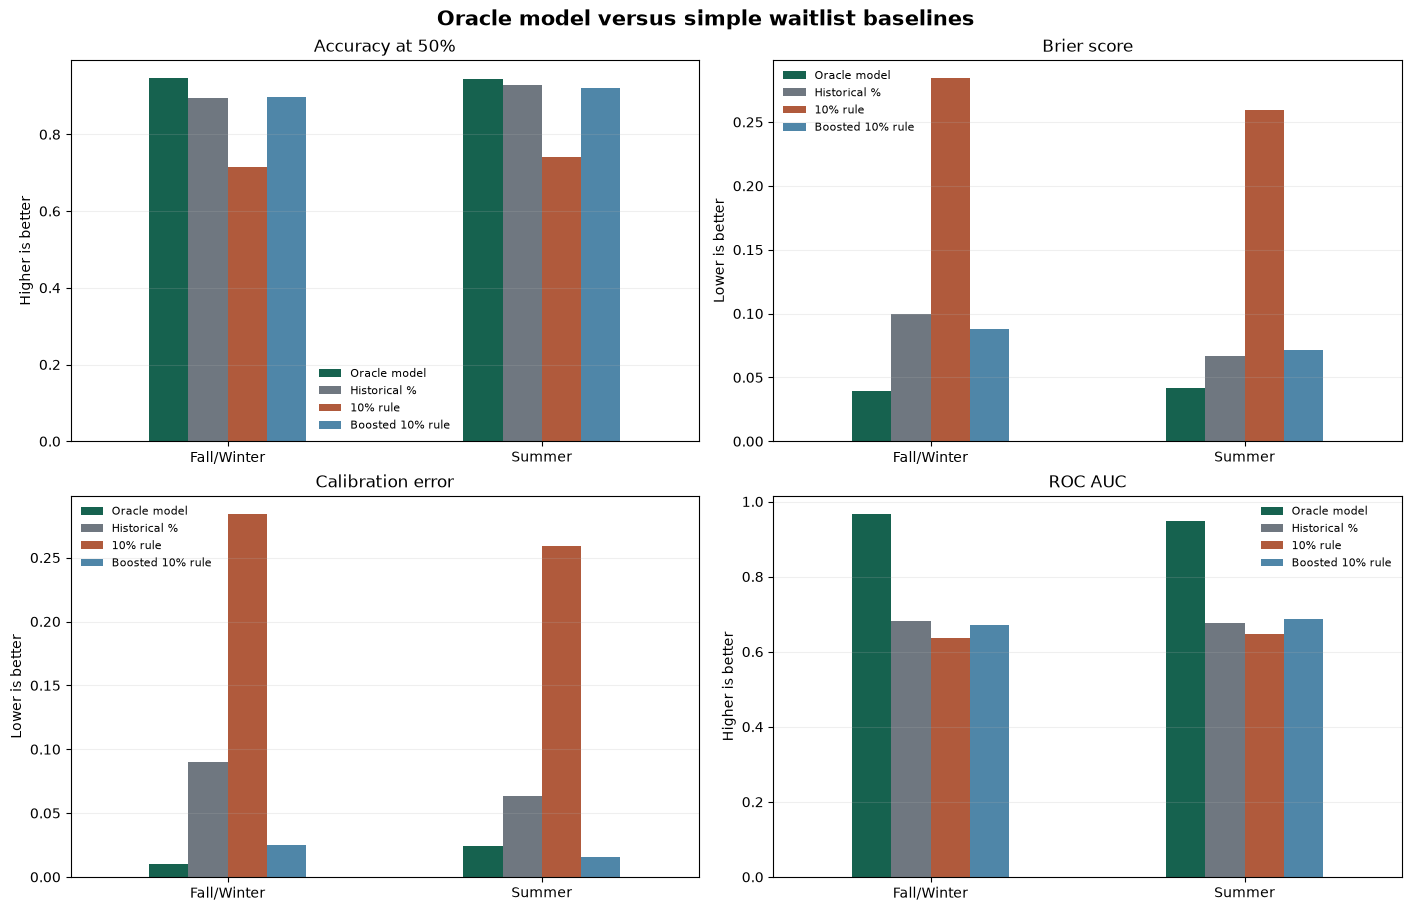

Saved metric benchmark to /student/anfazsha/oracle/docs/assets/model-baseline-benchmark.png


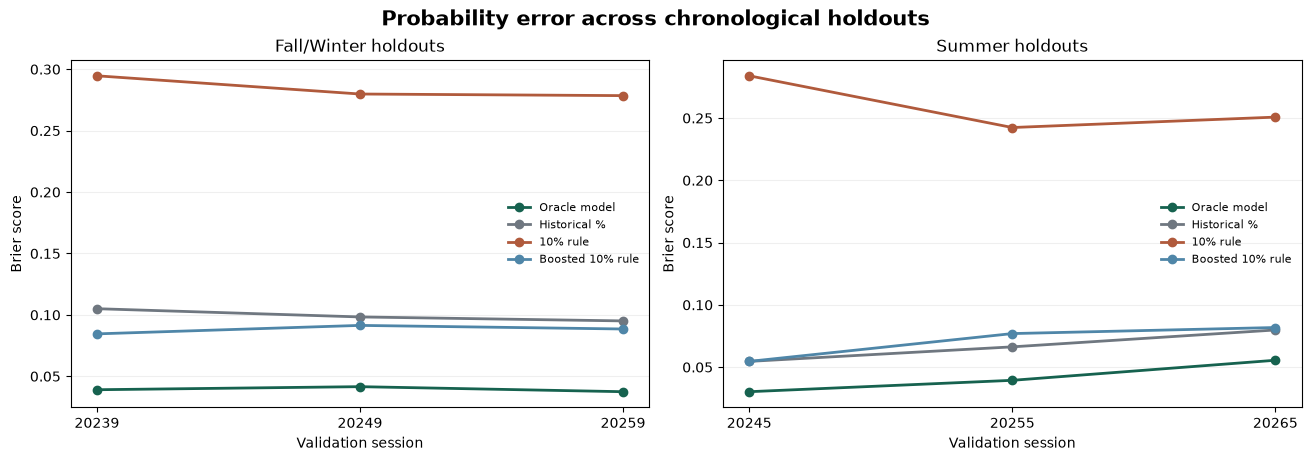

Saved chronological benchmark to /student/anfazsha/oracle/docs/assets/model-chronological-benchmark.png


In [8]:
OUTPUT_ROOT = PROJECT_ROOT / 'docs' / 'assets'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
methods = ['model', 'historical_percentage', '10_percent_rule', 'capacity_only']
labels = {
    'model': 'Oracle model',
    'capacity_only': 'Boosted 10% rule',
    'historical_percentage': 'Historical %',
    '10_percent_rule': '10% rule',
}
colors = {
    'model': '#16624f',
    'capacity_only': '#4f86a8',
    'historical_percentage': '#6f7780',
    '10_percent_rule': '#b05a3c',
}
season_names = {'fall_winter': 'Fall/Winter', 'summer': 'Summer'}
metrics = [
    ('mean_accuracy', 'Accuracy at 50%', 'Higher is better'),
    ('mean_brier', 'Brier score', 'Lower is better'),
    ('mean_ece', 'Calibration error', 'Lower is better'),
    ('mean_auc', 'ROC AUC', 'Higher is better'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (metric, title, direction) in zip(axes.flat, metrics):
    table = summary[metric].unstack('method')[methods]
    table.rename(index=season_names, columns=labels).plot(
        kind='bar', ax=ax, color=[colors[method] for method in methods],
    )
    ax.set(title=title, xlabel='', ylabel=direction)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Oracle model versus simple waitlist baselines', fontsize=15, fontweight='bold')
benchmark_path = OUTPUT_ROOT / 'model-baseline-benchmark.png'
fig.savefig(benchmark_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved metric benchmark to {benchmark_path}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, season in zip(axes, ['fall_winter', 'summer']):
    season_scores = scores[scores['season'].eq(season)]
    for method in methods:
        line = season_scores[season_scores['method'].eq(method)].sort_values('validation_session')
        ax.plot(
            line['validation_session'], line['brier'], marker='o', linewidth=2,
            label=labels[method], color=colors[method],
        )
    ax.set(title=f'{season_names[season]} holdouts', xlabel='Validation session', ylabel='Brier score')
    ax.grid(axis='y', alpha=.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Probability error across chronological holdouts', fontsize=15, fontweight='bold')
chronology_path = OUTPUT_ROOT / 'model-chronological-benchmark.png'
fig.savefig(chronology_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved chronological benchmark to {chronology_path}')

## Findings

Across six chronological holdouts, all four methods were scored on the same historical-comparable rows. Exact-rank historical coverage was **61.9%** of Fall/Winter validation weight and **53.9%** of Summer validation weight. Accuracy uses a 50% probability cutoff.

| Season | Method | Accuracy | Brier | ECE | ROC AUC |
|---|---|---:|---:|---:|---:|
| Fall/Winter | Oracle model | **94.6%** | **0.0394** | **0.0098** | **0.9673** |
| Fall/Winter | Historical percentage | 89.4% | 0.0995 | 0.0901 | 0.6813 |
| Fall/Winter | Literal 10% rule | 71.6% | 0.2843 | 0.2843 | 0.6366 |
| Fall/Winter | Boosted 10% rule | 89.7% | 0.0882 | 0.0251 | 0.6715 |
| Summer | Oracle model | **94.5%** | **0.0418** | 0.0245 | **0.9486** |
| Summer | Historical percentage | 92.9% | 0.0669 | 0.0632 | 0.6754 |
| Summer | Literal 10% rule | 74.1% | 0.2590 | 0.2590 | 0.6477 |
| Summer | Boosted 10% rule | 92.1% | 0.0711 | **0.0157** | 0.6868 |

The Oracle reduced mean Brier error by **55.4%** against the boosted 10% rule, **60.4%** against the historical percentage, and **86.2%** against the literal 10% rule in Fall/Winter. The Summer reductions were **41.3%**, **37.6%**, and **83.9%**. The Oracle had the best Brier score in every chronological holdout. The boosted 10% rule retained the lowest mean Summer ECE, while the Oracle led Summer accuracy, Brier score, and ROC AUC.